In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the Titanic dataset directly from the web
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Preview the data
print("Shape:", df.shape)
print(df.head())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [5]:
# See if any data is missing
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Drop columns we don't need
df = df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

# Fill missing Age with the average age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert Sex to numbers (ML models only understand numbers)
# male = 1, female = 0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Check no missing values remain
print("Missing values remaining:", df.isnull().sum().sum())
print("\nData now looks like:")
print(df.head())

Missing values remaining: 0

Data now looks like:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0


In [7]:
# Separate features (inputs) from target (what we predict)
X = df.drop('Survived', axis=1)  # everything except Survived
y = df['Survived']                # only Survived column

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model trained on {len(X_train)} passengers")
print(f"Model tested on {len(X_test)} passengers")
print(f"Accuracy: {accuracy:.2%}")

Model trained on 712 passengers
Model tested on 179 passengers
Accuracy: 82.12%


What influenced survival the most:
    Feature  Importance
1       Sex    0.272301
5      Fare    0.266766
2       Age    0.253908
0    Pclass    0.085709
3     SibSp    0.048704
4     Parch    0.038946
6  Embarked    0.033668


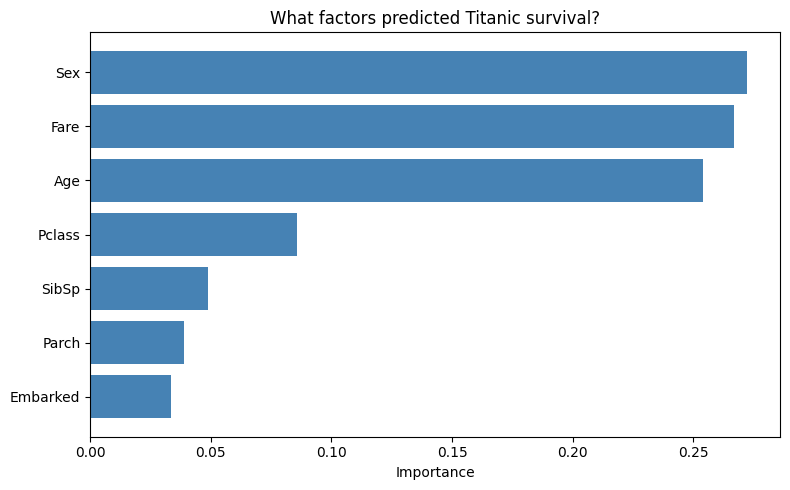

In [8]:
import matplotlib.pyplot as plt

# See which features mattered most to the model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("What influenced survival the most:")
print(feature_importance)

# Plot it
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('What factors predicted Titanic survival?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
import os
for f in os.listdir('/content'):
    print(f)

.config
sample_data
